# 기본 세팅

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -qq git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.4 MB/s eta 0:00:00


In [3]:
# 필요한 라이브러리 임포트

import os
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import clip
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

In [4]:
# 환경 세팅
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

seed=10
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed: {seed}")


Device: cuda
Seed: 10


In [ ]:
# 모든 경로는 본인 환경에 맞춰 수정!

# VGG 인코더, 디코더
- 출처: https://github.com/naoto0804/pytorch-AdaIN/tree/master (MIT License), Copyright (c) 2018 Naoto Inoue


In [5]:
# 인코더 정의
vgg = nn.Sequential(
    nn.Conv2d(3, 3, (1, 1)),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(3, 64, (3, 3)),
    nn.ReLU(), # relu1-1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 64, (3, 3)),
    nn.ReLU(), # relu1-2
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 128, (3, 3)),
    nn.ReLU(), # relu2-1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 128, (3, 3)),
    nn.ReLU(), # relu2-2
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 256, (3, 3)),
    nn.ReLU(), # relu3-1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(), # relu3-2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(), # relu3-3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(), # relu3-4
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 512, (3, 3)),
    nn.ReLU(), # relu4-1, 마지막으로 쓰이는 레이어
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu4-2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu4-3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu4-4
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu5-1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu5-2
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU(), # relu5-3
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 512, (3, 3)),
    nn.ReLU() # relu5-4
)

In [6]:
# 디코더 정의
decoder = nn.Sequential(
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(512, 256, (3, 3)),
    nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),
    nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 128, (3, 3)),
    nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 128, (3, 3)),
    nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 64, (3, 3)),
    nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 64, (3, 3)),
    nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 3, (3, 3)),
)

In [7]:
vgg.eval()
decoder.eval()

vgg_path = '/content/drive/MyDrive/Colab Notebooks/AIApp/vgg_normalised.pth'
decoder_path = '/content/drive/MyDrive/Colab Notebooks/AIApp/decoder.pth'

vgg.load_state_dict(torch.load(vgg_path))
decoder.load_state_dict(torch.load(decoder_path))

vgg.to(device)
decoder.to(device)

vgg = nn.Sequential(*list(vgg.children())[:31]) # ReLU4_1까지만 사용


# 감정 예측 및 피쳐 변환

In [8]:
# 모델 정의 및 가중치 불러오기

clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.float().eval()  # NaN 방지

class MLPClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.mlp(x)

num_classes = 4
feat_dim = 512
classifier = MLPClassifier(feat_dim, 256, num_classes).to(device)
classifier.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/AIApp/emotion_clip_weights.pth", map_location=device))
classifier.eval()

clip_preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                         (0.26862954, 0.26130258, 0.27577711))
])


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 46.3MiB/s]


In [9]:
# 변환 모델 선언 - 여러 번 실행하지 말 것

embedding_dim = 512
class_embedding = nn.Embedding(num_classes, embedding_dim).to(device).eval()
linear = nn.Linear(embedding_dim, 512).to(device).eval()


In [10]:
# 감정 예측 및 변환 함수
def predict_emotion(img_tensor, device, style_feat_shape):
    _, C, H, W = style_feat_shape

    if img_tensor.dim() == 4 and img_tensor.shape[0] == 1:
        img_tensor = img_tensor.squeeze(0)

    img_pil = transforms.ToPILImage()(img_tensor.cpu())
    img_proc = clip_preprocess(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        image_feat = clip_model.encode_image(img_proc).float()
        image_feat /= (image_feat.norm(dim=-1, keepdim=True) + 1e-6)

        logits = classifier(image_feat)
        pred_class = torch.argmax(logits, dim=1)
        if pred_class == 0:
            pred_name = 'anger'
        elif pred_class == 1:
            pred_name = 'fear'
        elif pred_class == 2:
            pred_name = 'happy'
        elif pred_class == 3:
            pred_name = 'sad'
        else:
            pred_name = 'unknown'

        print(f"Predicted Emotion Class: {pred_class.item()}, Predicted Emotion Name: {pred_name}")

        embedded = class_embedding(pred_class)
        final_output = linear(embedded)
        emotion_feat = final_output.view(1, C, 1, 1).expand(1, C, H, W)

    return emotion_feat.squeeze(0)


# AdaIN 및 가중치 조정
- calc_mean_std, AdaIN 함수 출처: https://github.com/naoto0804/pytorch-AdaIN/tree/master (MIT License), Copyright (c) 2018 Naoto Inoue

In [11]:
# 통계량 계산 함수
def calc_mean_std(feat, eps=1e-5):
    size = feat.size()
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

# AdaIN 처리 함수
def AdaIN(content_feat, style_feat):
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)
    normalized = (content_feat - content_mean) / content_std
    return normalized * style_std + style_mean

# 이미지 전처리 함수
def test_transform(size=512):
    if size != 0:
        return transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor()
        ])
    else:
        return transforms.ToTensor()

content_tf = test_transform()
style_tf = test_transform()

In [12]:
# 감정 가중치 조정 함수 정의
# 방법1
def fuse1(style_feat, emotion_feat, beta=0.5):
    fused_style = (1 - beta) * style_feat + beta * emotion_feat
    return fused_style

# 방법2
def fuse2(c_emotion_f, s_emotion_f, style_feat):
    if s_emotion_f.dim() == 3:
        s_emotion_f = s_emotion_f.unsqueeze(0)
    if c_emotion_f.dim() == 3:
        c_emotion_f = c_emotion_f.unsqueeze(0)

    s_emotion_resized = F.interpolate(
        s_emotion_f, size=c_emotion_f.shape[2:], mode='bilinear', align_corners=False
    )

    delta = c_emotion_f - s_emotion_resized

    delta_resized = F.interpolate(
        delta, size=style_feat.shape[2:], mode='bilinear', align_corners=False
    )

    fused_style = style_feat + delta_resized

    return fused_style

# 방법3
def fuse3(style_feat, emotion_feat):
  plused_style = style_feat + emotion_feat
  return plused_style

# 방법4
def fuse4(c_emotion_f, s_emotion_f, style_feat, beta=0.5):
    if s_emotion_f.dim() == 3:
        s_emotion_f = s_emotion_f.unsqueeze(0)
    if c_emotion_f.dim() == 3:
        c_emotion_f = c_emotion_f.unsqueeze(0)

    s_emotion_f_resized = F.interpolate(
        s_emotion_f, size=c_emotion_f.shape[2:], mode='bilinear', align_corners=False
    )

    delta_emotion = c_emotion_f - s_emotion_f_resized
    mod_style_feat = s_emotion_f_resized + beta * delta_emotion

    mod_style_feat_resized = F.interpolate(
        mod_style_feat, size=style_feat.shape[2:], mode='bilinear', align_corners=False
    )

    fused_style = style_feat + mod_style_feat_resized

    return fused_style

# 방법5
def fuse5(c_emotion_f, s_emotion_f, style_feat):
    if s_emotion_f.dim() == 3:
        s_emotion_f = s_emotion_f.unsqueeze(0)
    if c_emotion_f.dim() == 3:
        c_emotion_f = c_emotion_f.unsqueeze(0)

    s_emotion_resized = F.interpolate(
        s_emotion_f, size=c_emotion_f.shape[2:], mode='bilinear', align_corners=False
    )

    mean_emotion = 0.5 * (c_emotion_f + s_emotion_resized)

    mod_emotion_resized = F.interpolate(
        mean_emotion, size=style_feat.shape[2:], mode='bilinear', align_corners=False
    )

    fused_style = style_feat + mod_emotion_resized

    return fused_style

# 방법6
def fuse6(style_feat, emotion_feat):
    attention = torch.sigmoid(emotion_feat)  # [1, C, H, W]
    fused = style_feat * (1 + attention)
    return fused

# 방법7
def fuse7(style_feat, emotion_feat):
    def gram(x):
      if x.dim() == 3:
        x = x.unsqueeze(0)
      B, C, H, W = x.size()
      features = x.view(B, C, -1)
      return features @ features.transpose(1, 2) / (C * H * W)

    style_gram = gram(style_feat)
    emo_gram = gram(emotion_feat)

    correction = emo_gram - style_gram
    correction = correction.mean(dim=-1).view(1, -1, 1, 1)

    return style_feat + correction

# 방법8
def fuse8(style_feat, c_emotion_f, s_emotion_f, gamma=0.5, beta=0.5):
    if c_emotion_f.dim() == 3:
        c_emotion_f = c_emotion_f.unsqueeze(0)
    if s_emotion_f.dim() == 3:
        s_emotion_f = s_emotion_f.unsqueeze(0)

    c_emotion_resized = F.interpolate(c_emotion_f, size=style_feat.shape[2:], mode='bilinear', align_corners=False)
    s_emotion_resized = F.interpolate(s_emotion_f, size=style_feat.shape[2:], mode='bilinear', align_corners=False)

    blended_emotion = beta * c_emotion_resized + (1 - beta) * s_emotion_resized

    fused_style = (1 - gamma) * style_feat + gamma * blended_emotion

    return fused_style


In [13]:
# 방법에 따른 스타일 트랜스퍼 함수 정의
# 방법1
def style_transfer1(vgg, decoder, content, style, beta, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    emotion_f = predict_emotion(content, device, style_f.shape)
    fused_f = fuse1(style_f, emotion_f, beta)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법2
def style_transfer2(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    c_emotion_f = predict_emotion(content, device, content_f.shape)
    s_emotion_f = predict_emotion(style, device, style_f.shape)
    fused_f = fuse2(c_emotion_f, s_emotion_f, style_f)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법3
def style_transfer3(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    emotion_f = predict_emotion(content, device, style_f.shape)
    fused_f = fuse3(style_f, emotion_f)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법4
def style_transfer4(vgg, decoder, content, style, beta, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    c_emotion_f = predict_emotion(content, device, content_f.shape)
    s_emotion_f = predict_emotion(style, device, style_f.shape)
    fused_f = fuse4(c_emotion_f, s_emotion_f, style_f, beta)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법5
def style_transfer5(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    c_emotion_f = predict_emotion(content, device, content_f.shape)
    s_emotion_f = predict_emotion(style, device, style_f.shape)
    fused_f = fuse5(c_emotion_f, s_emotion_f, style_f)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법6
def style_transfer6(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    emotion_f = predict_emotion(content, device, style_f.shape)
    fused_f = fuse6(style_f, emotion_f)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법7
def style_transfer7(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    emotion_f = predict_emotion(content, device, style_f.shape)
    fused_f = fuse7(style_f, emotion_f)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 방법8
def style_transfer8(vgg, decoder, content, style, gamma, beta, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    c_emotion_f = predict_emotion(content, device, content_f.shape)
    s_emotion_f = predict_emotion(style, device, style_f.shape)
    fused_f = fuse8(style_f, c_emotion_f, s_emotion_f, gamma, beta)
    feat = AdaIN(content_f, fused_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 기존 AdaIN
def style_transfer(vgg, decoder, content, style, alpha=1.0):
    content_f = vgg(content)
    style_f = vgg(style)
    feat = AdaIN(content_f, style_f)
    feat = feat * alpha + content_f * (1 - alpha)
    return decoder(feat)

# 실행

In [28]:
content_path = '/content/drive/MyDrive/Colab Notebooks/AIApp/images/coco_sample/000000056343.jpg'
style_path = '/content/drive/MyDrive/Colab Notebooks/AIApp/images/wikiart_sample/000056.jpg'

content = content_tf(Image.open(str(content_path)))
style = style_tf(Image.open(str(style_path)))

style = style.to(device).unsqueeze(0)
content = content.to(device).unsqueeze(0)

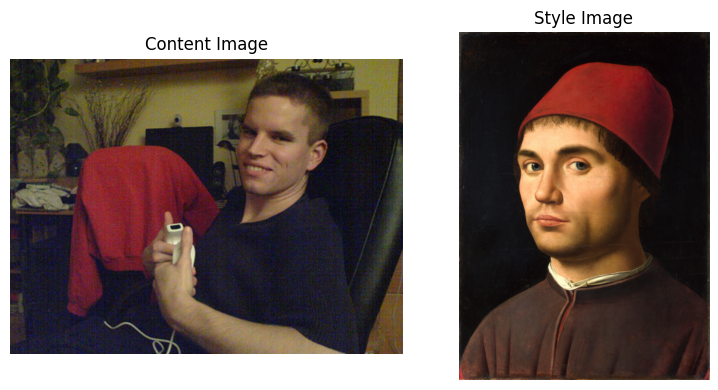

In [29]:
# 콘텐츠, 스타일 이미지 출력
content_img = content.squeeze(0).cpu()
style_img = style.squeeze(0).cpu()

content_img = TF.to_pil_image(content_img)
style_img = TF.to_pil_image(style_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(content_img)
axes[0].set_title('Content Image')
axes[0].axis('off')

axes[1].imshow(style_img)
axes[1].set_title('Style Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

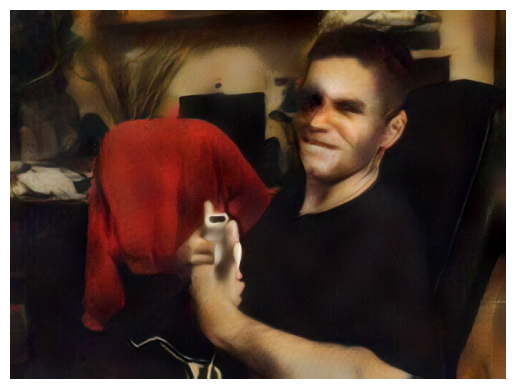

In [30]:
# 스타일 트랜스퍼 실행
with torch.no_grad():
    output = style_transfer(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy


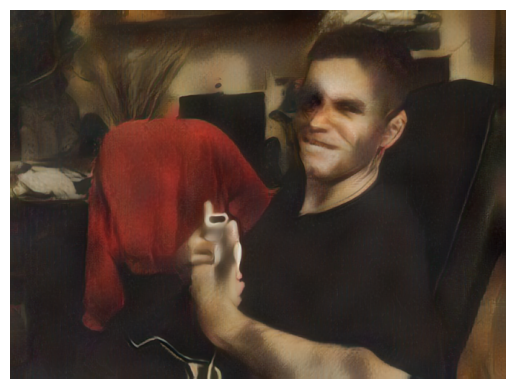

In [31]:
# 스타일 트랜스퍼 실행
with torch.no_grad():
    output = style_transfer1(vgg, decoder, content, style, alpha=1.0, beta=0.2)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy
Predicted Emotion Class: 3, Predicted Emotion Name: sad


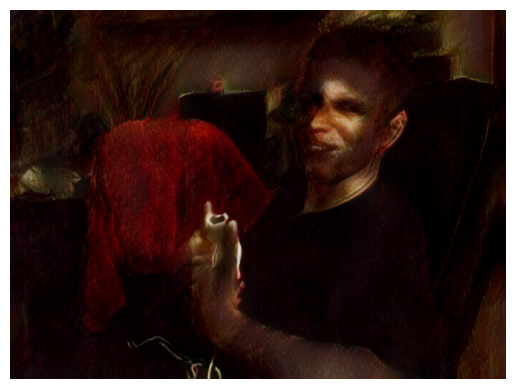

In [32]:
with torch.no_grad():
    output = style_transfer2(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy


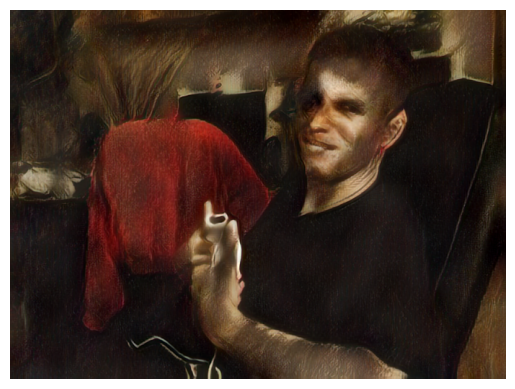

In [33]:
with torch.no_grad():
    output = style_transfer3(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy
Predicted Emotion Class: 3, Predicted Emotion Name: sad


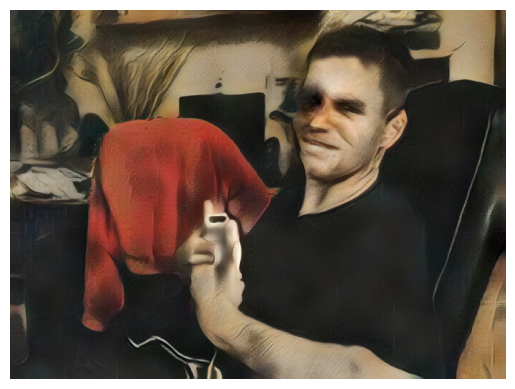

In [34]:
with torch.no_grad():
    output = style_transfer4(vgg, decoder, content, style, alpha=1.0, beta=0.2)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy
Predicted Emotion Class: 3, Predicted Emotion Name: sad


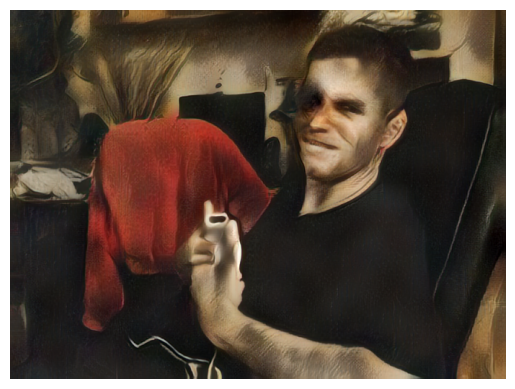

In [35]:
with torch.no_grad():
    output = style_transfer5(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy


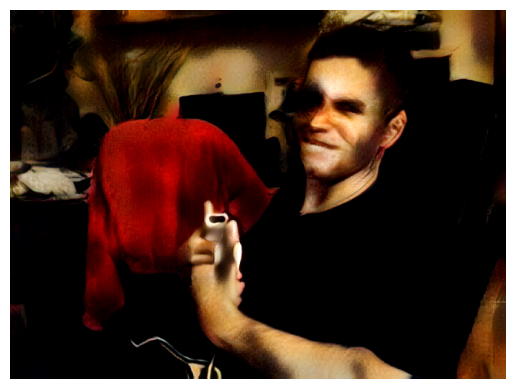

In [36]:
with torch.no_grad():
    output = style_transfer6(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy


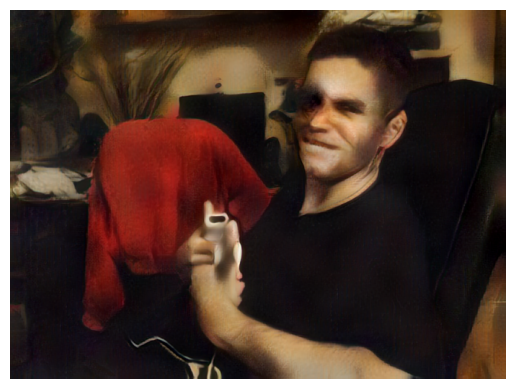

In [37]:
with torch.no_grad():
    output = style_transfer7(vgg, decoder, content, style, alpha=1.0)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()

Predicted Emotion Class: 2, Predicted Emotion Name: happy
Predicted Emotion Class: 3, Predicted Emotion Name: sad


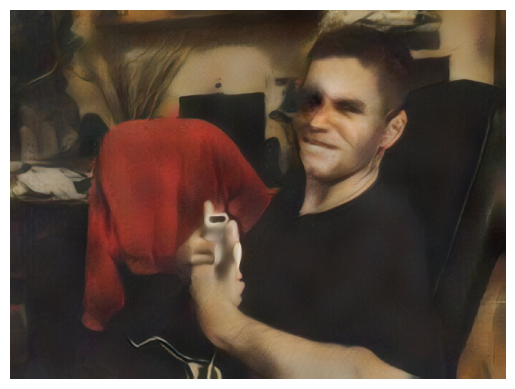

In [38]:
with torch.no_grad():
    output = style_transfer8(vgg, decoder, content, style, alpha=1.0, beta=0.2, gamma=0.2)

# 이미지 출력
output_img = output.squeeze(0).clamp(0, 1).cpu()
output_pil = TF.to_pil_image(output_img)

plt.imshow(output_pil)
plt.axis('off')
plt.show()